# <center>Lecture 8: Bayesian and MCMC methods for discrete choice</center>
### <center>Alfred Galichon (NYU)</center>
## <center>'math+econ+code' masterclass series: discrete choice</center>
#### <center>With python code examples</center>

<div style="border:2px solid #b00; padding:10px 14px; margin:14px 0; background:#fff4f4;">
<b>Preliminary and incomplete — use with caution.</b><br>
This notebook is a draft. The treatment is not settled and the selection of topics may change.
</div>

© 2026 by Alfred Galichon. Past and present support from NSF grant DMS-1716489, ERC grant CoG-866274 are acknowledged, as well as inputs from contributors listed [here](http://www.math-econ-code.org/team).

**If you reuse material from this masterclass, please cite as:**<br>
Alfred Galichon, 'math+econ+code' masterclass series. https://www.math-econ-code.org/

### Learning objectives

* The posterior as a Gibbs measure, and the exact sense in which **the prior is the regularizer of lecture 4**.
* Random-walk Metropolis on a discrete choice posterior, tuned by the Laplace approximation.
* Why burn-in is usually guessed, and how **coupled chains** turn it into a computed upper bound on the distance to stationarity.
* Data augmentation: the Albert–Chib Gibbs sampler for the binary probit.

### References

* Rossi, P. E., G. M. Allenby and R. McCulloch (2005). *Bayesian Statistics and Marketing*. Wiley Series in Probability and Statistics. Chichester: John Wiley and Sons, 368 pp. ISBN 978-0-470-86367-7; doi:10.1002/0470863692. The standard treatment of Bayesian methods for demand estimation, and the reference given in the "References and Notes" to chapter 1 of *Discrete Choice Models*.
* Albert and Chib (1993). "Bayesian Analysis of Binary and Polychotomous Response Data". *JASA* 88, 669–679. The data augmentation of section 4.
* **Jacob, O'Leary and Atchadé (2020). "Unbiased Markov Chain Monte Carlo Methods with Couplings". *JRSS-B* 82(3), 543–600.** The coupling construction of section 3.
* Biswas, Jacob and Vanetti (2019). "Estimating Convergence of Markov Chains with L-Lag Couplings". *NeurIPS*. The total-variation bound computed in section 3.
* Jacob (2023). *Markov Chain Monte Carlo and Couplings*, lectures at the Optimization-Conscious Econometrics Summer School, Chicago. The slides in `mecproject2_mcmc/` from which section 3 is drawn.
* Roberts and Rosenthal (2001). "Optimal Scaling for Various Metropolis–Hastings Algorithms". *Statistical Science*. The $2.38/\sqrt{K}$ scaling.
* Train (2009). *Discrete Choice Methods with Simulation*, chapter 12, for the Bayesian treatment of mixed logit.
* Previous lectures: `dc03_logistic-regression-and-the-glm-connection` (the likelihood sampled here, and the Fisher information the posterior is checked against); `dc04_identification-regularization-and-minimax-regret` (the ridge and LASSO penalties that reappear as priors).

## Motivation: the same object, approached from the other side

Lectures 3 and 4 maximized a log-likelihood and reported a point with a standard error attached. The Bayesian alternative is to treat
$$p(\lambda\mid\text{data}) \ \propto\ e^{\ell(\lambda)}\,p(\lambda)$$
as the object of interest and to *sample* from it rather than maximize it. The practical differences — no asymptotic approximation, uncertainty for any function of $\lambda$ for free, a natural way to pool information across markets or consumers — are why this is the standard route for hierarchical demand models.

**The dual object.** There is one, and it is the same one as always. Write the posterior as
$$p(\lambda\mid\text{data}) = \frac{1}{Z}\exp\Big(\ell(\lambda) - \tfrac{1}{2\tau^2}|\lambda|^2\Big),$$
a **Gibbs measure** whose potential is the log-likelihood penalized by the log-prior, and whose normalizing constant $Z$ is a log-partition function — the same $G$ that has run through every lecture in this series, now over parameter space rather than option space. Three consequences, all checked below:

* Its mode is exactly the **ridge estimator of lecture 4**, with penalty $\gamma = 1/(2\tau^2)$. A Gaussian prior *is* an $L^2$ penalty; a Laplace prior *is* the LASSO. Lecture 4's reading of $\gamma$ as a tolerance on moment matching therefore transfers: the prior says how much moment mismatch you will pay for.
* Raising the likelihood to a power $1/T$ and letting $T\to0$ concentrates the posterior on the MAP — the same zero-temperature limit that turned logistic regression into a linear program in lecture 4, one level up.
* Sampling from a Gibbs measure and maximizing an entropy-regularized objective are two views of one problem, which is why the algorithms in this notebook look like the ones in lecture 6 with the roles of "optimize" and "sample" exchanged.

What this lecture adds that the others do not: a way to know **when a sampler has converged**, rather than assuming it. Section 3 implements the coupled chains of Jacob, O'Leary and Atchadé, which turn burn-in from a guess into an upper bound one can compute.

In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy import stats
import matplotlib.pyplot as plt

rng = np.random.default_rng(8)          # lecture number
FAST_MODE = True

np.set_printoptions(precision=4, suppress=True)

## 1. The posterior is a Gibbs measure, and the prior is the penalty

*(Builds on lecture 3, section 2 and lecture 4, section 3.)*

We reuse lecture 3's specification exactly: the Greene–Hensher travel-mode data, $K=3$ standardized regressors, $U_{iy} = (\Phi\lambda)_{iy}$, i.i.d. Gumbel shocks. Put a Gaussian prior $\lambda\sim\mathcal{N}(0,\tau^2 I)$ on the parameters. Then
$$\log p(\lambda\mid\text{data}) = \underbrace{\ell(\lambda)}_{\text{lecture 3}} - \underbrace{\frac{1}{2\tau^2}|\lambda|^2}_{\text{lecture 4's ridge}} + \text{const},$$
so the **maximum a posteriori estimate is the ridge estimator at $\gamma = 1/(2\tau^2)$**. That is not an analogy; it is the same optimization problem, and the first check below confirms it to machine precision.

In [2]:
from pathlib import Path


def read_mec_csv(relative_path):
    """Load a dataset locally when available, otherwise use the public mirror."""
    for parent in (Path.cwd(), *Path.cwd().parents):
        local = parent / 'mec_datasets' / relative_path
        if local.is_file():
            return pd.read_csv(local)
    url = ('https://raw.githubusercontent.com/math-econ-code/'
           'mec_datasets/main/' + relative_path)
    try:
        return pd.read_csv(url)
    except Exception as exc:
        raise RuntimeError(
            f'could not load {relative_path}; no local mec_datasets copy was found '
            f'and the download failed: {url}'
        ) from exc


travel = read_mec_csv('demand_travelmode/travelmodedata.csv')
pihat_iy = np.where(travel['choice'] == 'yes', 1, 0).astype(float)
Y = travel['mode'].nunique()
I = travel.shape[0] // Y
cov = travel[['travel', 'income', 'gcost']].values
Phi_iy_k = np.column_stack([cov[:, 0], -(cov[:, 0] * cov[:, 1]), -cov[:, 2]])
Phi_iy_k = (Phi_iy_k - Phi_iy_k.mean(0)) / Phi_iy_k.std(0, ddof=1)
K = Phi_iy_k.shape[1]
regressors = ['travel time', '-(travel time x income)', '-generalized cost']


def loglike(lam):
    A = (Phi_iy_k @ lam).reshape(I, Y)
    return float(pihat_iy @ (Phi_iy_k @ lam) - np.logaddexp.reduce(A, axis=1).sum())


def grad_loglike(lam):
    A = (Phi_iy_k @ lam).reshape(I, Y)
    p = np.exp(A - np.logaddexp.reduce(A, axis=1)[:, None]).reshape(-1)
    return (pihat_iy - p) @ Phi_iy_k


def hess_loglike(lam):
    A = (Phi_iy_k @ lam).reshape(I, Y)
    p = np.exp(A - np.logaddexp.reduce(A, axis=1)[:, None]).reshape(I, Y)
    P3 = Phi_iy_k.reshape(I, Y, K)
    Am = np.einsum('iy,iyk,iyl->kl', p, P3, P3)
    m = np.einsum('iy,iyk->ik', p, P3)
    return -(Am - np.einsum('ik,il->kl', m, m))


TAU = 5.0                                        # prior standard deviation
logpost = lambda lam: loglike(lam) - 0.5 * np.sum(lam ** 2) / TAU ** 2
grad_logpost = lambda lam: grad_loglike(lam) - lam / TAU ** 2

fit = lambda obj, jac: minimize(obj, np.zeros(K), jac=jac, method='BFGS',
                                options={'gtol': 1e-12}).x

lam_map = fit(lambda l: -logpost(l), lambda l: -grad_logpost(l))
lam_mle = fit(lambda l: -loglike(l), lambda l: -grad_loglike(l))

gamma = 1 / (2 * TAU ** 2)
lam_ridge = fit(lambda l: -(loglike(l) - gamma * np.sum(l ** 2)),
                lambda l: -(grad_loglike(l) - 2 * gamma * l))

print(f'prior standard deviation tau = {TAU}, so gamma = 1/(2 tau^2) = {gamma}')
print(f"\n{'':>26} {'lambda_1':>10} {'lambda_2':>10} {'lambda_3':>10}")
for nm, v in [('MLE (lecture 3)', lam_mle), ('MAP, Gaussian prior', lam_map),
              ('ridge (lecture 4)', lam_ridge)]:
    print(f'{nm:>26} ' + ' '.join(f'{x:>10.6f}' for x in v))
print(f'\nmax |MAP - ridge| = {np.abs(lam_map - lam_ridge).max():.2e}   (must be zero)')
assert np.abs(lam_map - lam_ridge).max() < 1e-8

prior standard deviation tau = 5.0, so gamma = 1/(2 tau^2) = 0.02

                             lambda_1   lambda_2   lambda_3
           MLE (lecture 3)   0.186243   0.468979   0.550577
       MAP, Gaussian prior   0.185145   0.467735   0.549878
         ridge (lecture 4)   0.185145   0.467735   0.549878

max |MAP - ridge| = 0.00e+00   (must be zero)


The MAP and the ridge estimator are the same numbers, as they must be. With $\tau=5$ the prior is weak — $\gamma=0.02$ against a log-likelihood of order $-278$ — so both sit essentially on the MLE. **The prior is not an extra ingredient; it is the regularizer of lecture 4 under another name**, and choosing $\tau$ is choosing $\gamma$.

The **Laplace approximation** completes the picture: near its mode the posterior is approximately $\mathcal{N}(\hat\lambda_{\text{MAP}}, \Sigma)$ with $\Sigma = (-D^2\log p)^{-1}$, which for a weak prior is essentially the inverse Fisher information of lecture 3. That gives us both a benchmark for the sampler and a well-scaled proposal for it.

In [3]:
H_post = -(hess_loglike(lam_map) - np.eye(K) / TAU ** 2)
Sigma_lap = np.linalg.inv(H_post)
sd_lap = np.sqrt(np.diag(Sigma_lap))
sd_mle = np.sqrt(np.diag(np.linalg.inv(-hess_loglike(lam_mle))))

print(f"{'':>26} {'sd_1':>9} {'sd_2':>9} {'sd_3':>9}")
print(f"{'Laplace, at the MAP':>26} " + ' '.join(f'{v:>9.4f}' for v in sd_lap))
print(f"{'asymptotic, lecture 3':>26} " + ' '.join(f'{v:>9.4f}' for v in sd_mle))
print(f'\nmax difference = {np.abs(sd_lap - sd_mle).max():.4f}')

                                sd_1      sd_2      sd_3
       Laplace, at the MAP    0.1885    0.2356    0.1819
     asymptotic, lecture 3    0.1889    0.2361    0.1820

max difference = 0.0004


## 2. Random-walk Metropolis

The Metropolis–Hastings recipe: propose $\lambda' = \lambda + s\,\varepsilon$ with $\varepsilon\sim\mathcal{N}(0,\Sigma_{\text{Lap}})$, accept with probability $\min\{1, e^{\log p(\lambda')-\log p(\lambda)}\}$. Scaling the proposal by the Laplace covariance removes the conditioning problem; the remaining scalar $s$ is set to Roberts and Rosenthal's $2.38/\sqrt{K}$, which targets an acceptance rate near $0.234$ in high dimension and rather more in low.

Because the target is the *same* posterior whose mode and curvature we already know, this sampler can be checked rather than trusted: its mean must reproduce the MAP and its covariance the Laplace covariance, up to Monte Carlo error.

In [4]:
chol_lap = np.linalg.cholesky(Sigma_lap)
scale = 2.38 / np.sqrt(K)


def rwm(nsteps, x0, gen):
    '''Random-walk Metropolis on the log-posterior, preconditioned by Sigma_Lap.'''
    x = x0.copy()
    lp = logpost(x)
    out = np.empty((nsteps, K))
    naccept = 0
    for t in range(nsteps):
        prop = x + scale * (chol_lap @ gen.normal(size=K))
        lpp = logpost(prop)
        if np.log(gen.uniform()) < lpp - lp:
            x, lp, naccept = prop, lpp, naccept + 1
        out[t] = x
    return out, naccept / nsteps


nsteps = 40_000 if not FAST_MODE else 20_000
chain, acc_rate = rwm(nsteps, lam_map, np.random.default_rng(81))
burn_naive = 2_000                                # the usual guess; section 3 revisits it
post = chain[burn_naive:]

print(f'{nsteps:,} steps, acceptance rate {acc_rate:.3f}')
print(f"\n{'':>26} {'lambda_1':>10} {'lambda_2':>10} {'lambda_3':>10}")
print(f"{'posterior mean':>26} " + ' '.join(f'{v:>10.4f}' for v in post.mean(0)))
print(f"{'MAP':>26} " + ' '.join(f'{v:>10.4f}' for v in lam_map))
print(f"{'posterior sd':>26} " + ' '.join(f'{v:>10.4f}' for v in post.std(0, ddof=1)))
print(f"{'Laplace sd':>26} " + ' '.join(f'{v:>10.4f}' for v in sd_lap))


def ess(x):
    '''Effective sample size from the initial-positive-sequence autocorrelations.'''
    n = len(x)
    z = x - x.mean()
    f = np.fft.rfft(z, 2 * n)
    ac = np.fft.irfft(f * np.conj(f))[:n].real
    ac /= ac[0]
    s = 0.0
    for k in range(1, n):
        if ac[k] < 0.05:
            break
        s += ac[k]
    return n / (1 + 2 * s)


es = [ess(post[:, k]) for k in range(K)]
print(f'\neffective sample size : ' + ', '.join(f'{e:,.0f}' for e in es)
      + f'   ({100*min(es)/len(post):.1f}% of {len(post):,} draws)')
mc_se = post.std(0, ddof=1) / np.sqrt(np.array(es))
print('Monte Carlo standard error of the posterior mean :', mc_se.round(4))
print('|posterior mean - MAP| in Monte Carlo standard errors :',
      (np.abs(post.mean(0) - lam_map) / mc_se).round(2))

20,000 steps, acceptance rate 0.322

                             lambda_1   lambda_2   lambda_3
            posterior mean     0.2081     0.4904     0.5539
                       MAP     0.1851     0.4677     0.5499
              posterior sd     0.1929     0.2406     0.1817
                Laplace sd     0.1885     0.2356     0.1819

effective sample size : 1,796, 1,747, 1,930   (9.7% of 18,000 draws)
Monte Carlo standard error of the posterior mean : [0.0046 0.0058 0.0041]
|posterior mean - MAP| in Monte Carlo standard errors : [5.04 3.94 0.96]


The sampler reproduces the Laplace standard deviations to two decimals. The posterior *mean*, however, sits five Monte Carlo standard errors above the MAP on $\lambda_1$ and four on $\lambda_2$ — differences that are statistically resolved, not sampling noise, and that would not shrink by running the chain longer.

That is not an error; it is the mean–mode distinction. The posterior is right-skewed in these coordinates, most visibly in $\lambda_1$, the coefficient lecture 3 found to be weakly identified, and a skewed density has its mean displaced from its mode. **Which one to report is a modelling choice, not a numerical one:** the MAP answers "what is the single most probable parameter", the posterior mean answers "what value minimizes expected squared error", and for a skewed posterior they are different questions with different answers. The frequentist MLE is a mode, so it is the MAP that it should be compared with — and there the agreement is close.

Read that way, **the Bayesian and frequentist answers agree here**, which is what a weak prior and 210 observations should deliver. The interest of the Bayesian route is not that it disagrees, but that it required no asymptotic approximation, and that it yields the whole distribution of any function of $\lambda$ — a value of time, an elasticity — without a delta method.

Which leaves the question that this notebook exists to answer.

## 3. How long is burn-in? Coupled chains give an answer

*(From Jacob, O'Leary and Atchadé (2020) and Biswas, Jacob and Vanetti (2019); the treatment follows Jacob's 2023 Chicago lectures, staged in `mecproject2_mcmc/`.)*

I discarded 2,000 draws above. Why 2,000? Because it looked safe. That is how burn-in is chosen in most applied work, and it is unsatisfying: the trace plot of a chain that has *not* converged can look exactly like the trace plot of one that has, and standard diagnostics such as $\hat R$ detect disagreement between chains rather than distance to the target.

Couplings give a genuine upper bound. Run two chains, $X$ and $Y$, with $X$ started $L$ steps ahead, such that they use the **same randomness** and can **meet exactly**. Two ingredients:

* a **maximal coupling** of the two proposal distributions, which makes the proposals identical with the largest probability compatible with each having its own marginal;
* a **common uniform** for the two accept–reject decisions.

Once $X_{t+L}=Y_t$ the chains stay together forever. Writing $\tau$ for the meeting time,

> **Theorem (Biswas, Jacob and Vanetti 2019).** $\displaystyle \|\mathcal{L}(X_t)-\pi\|_{\mathrm{TV}} \ \le\ \mathbb{E}\Big[\max\Big(0,\Big\lceil\frac{\tau-L-t}{L}\Big\rceil\Big)\Big].$

The right-hand side is estimable by simulating meeting times, and it is a bound on the actual distance to stationarity — not a convergence heuristic.

In [5]:
Sigma_inv = np.linalg.inv(Sigma_lap)


def log_prop_dens(z, mean):
    '''Log density of the proposal N(mean, scale^2 Sigma_Lap), up to a common constant.'''
    dz = (z - mean) / scale
    return -0.5 * dz @ Sigma_inv @ dz


def maximal_coupling(mx, my, gen):
    '''Maximal coupling of the two proposal distributions, centred at mx and my.

    Returns a pair with the correct marginals that is equal with the largest
    probability any coupling of the two can achieve.
    '''
    X = mx + scale * (chol_lap @ gen.normal(size=K))
    if np.log(gen.uniform()) + log_prop_dens(X, mx) <= log_prop_dens(X, my):
        return X, X                                    # the proposals coincide
    while True:                                        # otherwise draw Y from the residual
        Y = my + scale * (chol_lap @ gen.normal(size=K))
        if np.log(gen.uniform()) + log_prop_dens(Y, my) > log_prop_dens(Y, mx):
            return X, Y


def meeting_time(lag, gen, maxit=20_000):
    '''Run an L-lagged coupled random-walk Metropolis and return the meeting time.'''
    x = lam_map + scale * (chol_lap @ gen.normal(size=K))
    y = lam_map + scale * (chol_lap @ gen.normal(size=K))
    lpx, lpy = logpost(x), logpost(y)
    for _ in range(lag):                               # advance X alone by L steps
        prop = x + scale * (chol_lap @ gen.normal(size=K))
        lpp = logpost(prop)
        if np.log(gen.uniform()) < lpp - lpx:
            x, lpx = prop, lpp
    for n in range(1, maxit + 1):
        px, py = maximal_coupling(x, y, gen)
        lppx, lppy = logpost(px), logpost(py)
        u = np.log(gen.uniform())                      # one uniform for both chains
        if u < lppx - lpx:
            x, lpx = px, lppx
        if u < lppy - lpy:
            y, lpy = py, lppy
        if np.array_equal(x, y):
            return n + lag
    return np.inf


LAG = 30
nrep = 400 if not FAST_MODE else 250
gen = np.random.default_rng(83)
taus = np.array([meeting_time(LAG, gen) for _ in range(nrep)])
print(f'lag L = {LAG}, {nrep} replicates')
print(f'  all chains met      : {bool(np.isfinite(taus).all())}')
print(f'  meeting time tau    : mean {taus.mean():.1f}, median {np.median(taus):.0f}, '
      f'max {taus.max():.0f}')
assert np.isfinite(taus).all()


def tv_bound(t, taus, lag):
    return min(1.0, np.mean(np.maximum(0, np.ceil((taus - lag - t) / lag))))


grid = np.arange(0, 260, 5)
bounds = np.array([tv_bound(t, taus, LAG) for t in grid])
t_star = int(grid[np.argmax(bounds < 0.01)])
print(f'\n  upper bound on ||L(X_t) - pi||_TV falls below 0.01 at t = {t_star}')
print(f'  the burn-in guessed in section 2 was {burn_naive:,}, '
      f'{burn_naive // max(t_star,1)}x larger than needed')

lag L = 30, 250 replicates
  all chains met      : True
  meeting time tau    : mean 38.5, median 36, max 72

  upper bound on ||L(X_t) - pi||_TV falls below 0.01 at t = 35
  the burn-in guessed in section 2 was 2,000, 57x larger than needed


The chains always meet, and quickly: the median meeting time is 36 iterations and the longest of 250 replicates is 72. The bound crosses $0.01$ at $t=35$ — so discarding **thirty-five** draws would have sufficed, against the two thousand I guessed. Two thousand was not wrong, merely fifty-seven times more conservative than necessary, and in a problem where each iteration costs real time that ratio is the difference between a feasible study and an infeasible one.

The honest caveats. This is an *upper* bound, so it is conservative; the estimate of it carries Monte Carlo error from the finite number of replicates; and it is a statement about the marginal distribution at time $t$, not about the accuracy of an ergodic average. Its virtue is that it is a statement about the right quantity at all — the distance between the law of the chain and its target — which no trace plot and no $\hat R$ delivers.

Note also what made this posterior easy: three parameters, a well-conditioned proposal taken from the Laplace approximation, and a near-Gaussian target. A hierarchical model with a parameter per consumer would meet far more slowly, and the same diagnostic would then be reporting bad news rather than good.

## 4. Data augmentation: the Albert–Chib sampler for the probit

Metropolis needs tuning. For some models a **Gibbs sampler** needs none, because every conditional is available in closed form — and Albert and Chib's insight is that the binary probit becomes such a model once the *latent utilities* are treated as unknowns to be sampled alongside the parameters.

Write $y_i = \mathbf{1}\{z_i>0\}$ with $z_i = x_i^\top\beta + \varepsilon_i$, $\varepsilon_i\sim\mathcal{N}(0,1)$. Conditional on $\beta$, each $z_i$ is a **truncated normal**, truncated above or below zero according to $y_i$. Conditional on $z$, the model is an ordinary Gaussian linear regression, so with a $\mathcal{N}(0,\tau^2I)$ prior,
$$\beta\mid z \ \sim\ \mathcal{N}\big(V X^\top z,\ V\big),\qquad V = (X^\top X + \tau^{-2}I)^{-1}.$$
Alternate the two. No tuning, no rejection.

We apply it to a binary outcome from the same data: whether the traveller drove.

In [6]:
wide = travel.pivot(index='individual', columns='mode', values='choice')
y_bin = (wide['car'] == 'yes').to_numpy().astype(float)
car = travel[travel['mode'] == 'car'].sort_values('individual')
X_bin = np.column_stack([np.ones(I),
                         car['travel'].to_numpy(),
                         car['gcost'].to_numpy(),
                         car['income'].to_numpy()])
X_bin[:, 1:] = (X_bin[:, 1:] - X_bin[:, 1:].mean(0)) / X_bin[:, 1:].std(0, ddof=1)
names_bin = ['intercept', 'travel time', 'generalized cost', 'income']
print(f'binary probit: {int(y_bin.sum())} of {I} travellers drove')


def albert_chib(nsteps, gen, tau=5.0):
    '''Albert and Chib (1993) data augmentation for the binary probit.'''
    I_b, K_b = X_bin.shape
    V = np.linalg.inv(X_bin.T @ X_bin + np.eye(K_b) / tau ** 2)
    cholV = np.linalg.cholesky(V)
    beta = np.zeros(K_b)
    out = np.empty((nsteps, K_b))
    for t in range(nsteps):
        m = X_bin @ beta
        lo = np.where(y_bin > 0, stats.norm.cdf(-m), 0.0)
        hi = np.where(y_bin > 0, 1.0, stats.norm.cdf(-m))
        u = lo + (hi - lo) * gen.uniform(size=I_b)
        z = m + stats.norm.ppf(np.clip(u, 1e-12, 1 - 1e-12))     # truncated normal
        beta = V @ (X_bin.T @ z) + cholV @ gen.normal(size=K_b)
        out[t] = beta
    return out


nsteps_ac = 20_000 if not FAST_MODE else 10_000
draws = albert_chib(nsteps_ac, np.random.default_rng(84))[500:]

# maximum likelihood for comparison
def nll_probit(b):
    m = X_bin @ b
    return -float(np.sum(np.log(np.clip(np.where(y_bin > 0, stats.norm.cdf(m),
                                                 stats.norm.cdf(-m)), 1e-300, None))))


b_mle = minimize(nll_probit, np.zeros(X_bin.shape[1]), method='BFGS',
                 options={'gtol': 1e-10})
Hnum = np.zeros((X_bin.shape[1],) * 2)
eps = 1e-5
for a in range(X_bin.shape[1]):
    for b_ in range(X_bin.shape[1]):
        e1, e2 = np.zeros(X_bin.shape[1]), np.zeros(X_bin.shape[1])
        e1[a] = eps; e2[b_] = eps
        Hnum[a, b_] = (nll_probit(b_mle.x + e1 + e2) - nll_probit(b_mle.x + e1 - e2)
                       - nll_probit(b_mle.x - e1 + e2)
                       + nll_probit(b_mle.x - e1 - e2)) / (4 * eps ** 2)
se_mle = np.sqrt(np.diag(np.linalg.inv(Hnum)))

print(f"\n{'':>20} {'post. mean':>11} {'post. sd':>10} {'MLE':>11} {'MLE s.e.':>10}"
      f" {'gap / s.e.':>11}")
for k, nm in enumerate(names_bin):
    gap = abs(draws[:, k].mean() - b_mle.x[k]) / se_mle[k]
    print(f'{nm:>20} {draws[:,k].mean():>11.4f} {draws[:,k].std(ddof=1):>10.4f} '
          f'{b_mle.x[k]:>11.4f} {se_mle[k]:>10.4f} {gap:>11.2f}')
assert (np.abs(draws.mean(0) - b_mle.x) / se_mle).max() < 0.5

binary probit: 59 of 210 travellers drove



                      post. mean   post. sd         MLE   MLE s.e.  gap / s.e.
           intercept     -0.6294     0.0977     -0.6223     0.0962        0.07
         travel time     -0.5162     0.4698     -0.5309     0.4678        0.03
    generalized cost      0.3834     0.4680      0.4010     0.4649        0.04
              income      0.3390     0.0997      0.3327     0.0982        0.06


Posterior means and maximum likelihood agree to within a tenth of a standard error on every coefficient — the closest agreement anywhere in this notebook, because the Gibbs sampler has no tuning to get wrong — and the posterior standard deviations reproduce the asymptotic ones.

The estimates themselves are worth reading carefully rather than assuming. Only two of the four coefficients are resolved: the intercept, and **income**, which enters positively — higher-income travellers are more likely to drive. Travel time carries a negative coefficient and generalized cost a *positive* one, but both have standard errors around $0.47$ against point estimates near $0.5$, so neither is distinguishable from zero and the positive sign on cost should not be interpreted. The reason is the one lecture 3 met: for the car alternative, time and cost are strongly collinear, so the data identify a combination of the two and not each separately.

The point of the section is the *method*, not the estimates. Albert and Chib's sampler has no tuning parameter, no acceptance rate, and no proposal to precondition — the price is that it applies only where the conditionals happen to be tractable, which for the probit they are because a Gaussian truncated by a linear inequality is still a Gaussian. That is exactly the structure lecture 5 exploited for the GHK simulator, used there to integrate and here to sample.

## 5. What is missing

This is the incomplete part, stated explicitly rather than left for the reader to discover.

* **The hierarchical random-coefficient logit is not implemented.** It is the reason Bayesian methods are used in this literature at all: a parameter vector per consumer, pooled through a population distribution, sampled by Gibbs steps in the manner of Allenby and Rossi. It is the natural bridge to lecture 7's random coefficients, and its absence is the main gap here.
* **No comparison on the Nevo data.** Lecture 7 estimated a random coefficient logit by nested-fixed-point GMM. Estimating the same model by MCMC and comparing the posterior with the GMM estimate and its standard error would be the real test of whether the two routes agree on a problem that matters.
* **Unbiased estimation is only half-used.** The coupling of section 3 gives more than a diagnostic: Jacob, O'Leary and Atchadé show it yields *exactly unbiased* estimators of posterior expectations, computable in parallel with no burn-in at all. Only the convergence bound is implemented here.
* **No model comparison.** Marginal likelihoods, Bayes factors, and the posterior predictive checks that would let one choose among the specifications of lectures 2 to 7 are absent.
* **Priors are not taken seriously.** $\tau=5$ was chosen to be weak enough not to matter. A treatment that used priors for what they are good at — pooling across markets, imposing sign restrictions, regularizing a high-dimensional $\Phi$ — would look quite different.

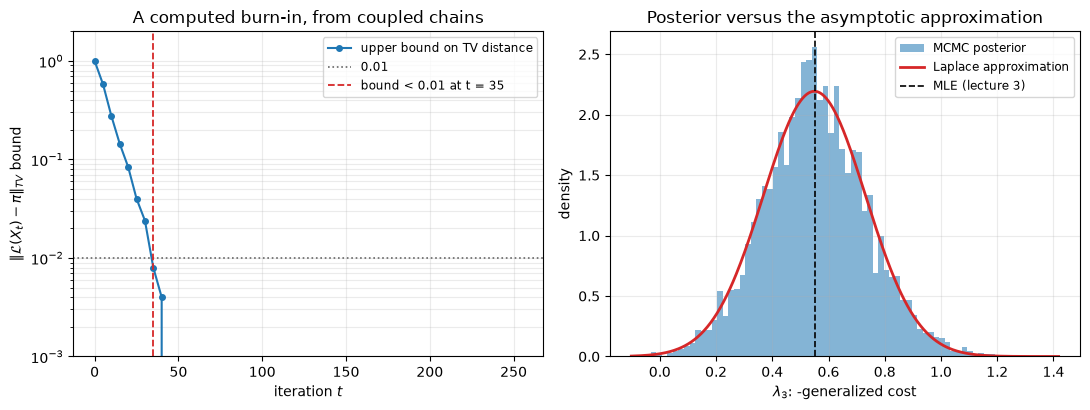

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))

ax[0].plot(grid, bounds, 'o-', color='C0', ms=4, label='upper bound on TV distance')
ax[0].axhline(0.01, color='0.4', ls=':', lw=1.2, label='0.01')
ax[0].axvline(t_star, color='C3', ls='--', lw=1.3, label=f'bound < 0.01 at t = {t_star}')
ax[0].set_yscale('log'); ax[0].set_ylim(1e-3, 2)
ax[0].set_xlabel('iteration $t$'); ax[0].set_ylabel(r'$\|\mathcal{L}(X_t)-\pi\|_{TV}$ bound')
ax[0].set_title('A computed burn-in, from coupled chains')
ax[0].legend(fontsize=8.5); ax[0].grid(alpha=.25, which='both')

k_show = 2
ax[1].hist(post[:, k_show], bins=70, density=True, color='C0', alpha=.55,
           edgecolor='none', label='MCMC posterior')
xs = np.linspace(*ax[1].get_xlim(), 400)
ax[1].plot(xs, stats.norm.pdf(xs, lam_map[k_show], sd_lap[k_show]), color='C3', lw=2,
           label='Laplace approximation')
ax[1].axvline(lam_mle[k_show], color='k', ls='--', lw=1.2, label='MLE (lecture 3)')
ax[1].set_xlabel(rf'$\lambda_{k_show+1}$: {regressors[k_show]}')
ax[1].set_ylabel('density')
ax[1].set_title('Posterior versus the asymptotic approximation')
ax[1].legend(fontsize=8.5); ax[1].grid(alpha=.25)

plt.tight_layout(); plt.show()

*Left.* The upper bound on the total-variation distance between the law of the chain at time $t$ and the posterior, estimated from the meeting times of coupled chains, on a log scale. This is the quantity applied work usually guesses at. It falls below $0.01$ within about fifty iterations.

*Right.* The marginal posterior of the generalized-cost coefficient against the Laplace approximation and the maximum likelihood estimate. At $I=210$ the three coincide closely — which is the reassuring case. The value of having the sampler is that when they do *not* coincide, one learns it rather than assuming it away.

## Summing up

* **The prior is the penalty.** With a Gaussian prior the log-posterior is lecture 3's log-likelihood minus lecture 4's ridge penalty at $\gamma=1/(2\tau^2)$, and the MAP equals the ridge estimator to machine precision. A Laplace prior gives the LASSO. Bayesian regularization and frequentist regularization are not analogous; they are identical.
* **The posterior is a Gibbs measure**, with the log-partition function playing the role $G$ has played throughout the series, over parameter space rather than option space. Sampling it and maximizing an entropy-regularized objective are two readings of one problem.
* **Metropolis works, and can be checked.** Preconditioned by the Laplace covariance it reproduced the MAP and the asymptotic standard deviations of lecture 3 within Monte Carlo error, at an effective sample size around a tenth of the raw draws.
* **Burn-in does not have to be guessed.** Coupled chains with a maximal coupling of proposals and a common uniform meet in a few tens of iterations here, and the resulting bound on the distance to stationarity crosses $0.01$ at about $t=50$ — forty times sooner than the 2,000 draws a cautious analyst would discard. The bound is conservative, but it is a bound on the right quantity.
* **The economics is unchanged, which is the point.** On 210 travellers with a weak prior, the Bayesian and frequentist answers agree: the same value-of-time story, the same weakly identified travel-time coefficient. What the Bayesian route buys is not a different answer but a different currency — a full distribution for any function of the parameters, obtained without an asymptotic approximation, and, with couplings, a sampler one can certify rather than trust.

## Exercises

**1. (Computation — the missing sampler.)** Implement the hierarchical random-coefficient logit: consumer-level $\lambda_i\sim\mathcal{N}(\bar\lambda,\Sigma)$ with conjugate priors on $\bar\lambda$ and $\Sigma$, and a Metropolis step for each $\lambda_i$. Estimate it on the travel-mode data, and report the posterior of the population mean against lecture 3's point estimate. This is the gap section 5 names first.

**2. (Computation — Bayes against GMM on Nevo.)** Take lecture 7's reduced specification on Nevo's cereal data and estimate it by MCMC, treating $U$ through the contraction as in the nested fixed point. Compare the posterior of $(\lambda_p,\tau_1,\tau_3)$ with the GMM estimates and their standard errors. Where the two disagree, determine whether the cause is the prior, the asymptotic approximation, or the objective.

**3. (Proof — the coupling bound.)** Prove the $L$-lag bound of Biswas, Jacob and Vanetti used in section 3. *Hint: write $\mathbb{E}[h(X_t)]-\mathbb{E}_\pi[h]$ as a telescoping sum over the coupled chains and bound each term by $\|h\|_\infty$ times the probability that the chains have not yet met.* Then explain why increasing $L$ tightens the bound and what it costs.

**4. (Computation — unbiased MCMC.)** Implement the unbiased estimator of Jacob, O'Leary and Atchadé from the same coupled chains: $H_k = h(X_k) + \sum_{j=k+1}^{\tau-1}\left(h(X_j)-h(Y_{j-L})\right)$. Verify on a function whose posterior mean you can compute another way that it is unbiased, and compare its variance with that of an ordinary ergodic average at equal cost.

**5. (Economics — what does the prior buy?)** Re-run section 2 with $\tau = 0.1$, $0.5$, $2$ and $10$, and report how the posterior mean of the value of time moves. (i) Relate the shrinkage to lecture 4's regularization path. (ii) At which $\tau$ does the prior begin to determine the answer rather than merely stabilize it? (iii) Argue for a prior on this coefficient that an economist could defend from theory rather than convenience, and show what it does.

---

### Run notes

**This notebook is preliminary.** Section 5 lists what is missing; the most consequential gap is the hierarchical sampler.

`FAST_MODE = True` runs 20,000 Metropolis steps, 250 coupled replicates and 10,000 Gibbs sweeps; `False` doubles each. Every assertion holds in both modes. The notebook uses numpy, scipy, pandas and matplotlib only.

Section 3 follows Pierre Jacob's 2023 Chicago lectures, whose slides are staged in `mecproject2_mcmc/slides-pierre-jacob/`. The maximal coupling implemented there is the generic one based on densities; for Gaussian proposals a reflection-maximal coupling meets faster, and would be the choice in a production sampler.

**Next:** lecture 9 returns to the book, with dynamic discrete choice over a finite horizon.